# Importing Library

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom , RandomTranslation , RandomContrast , RandomBrightness
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2

2025-09-28 03:15:31.789893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Importing Dataset

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 6799 files belonging to 3 classes.
Using 5440 files for training.


I0000 00:00:1759007742.120069     755 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 6799 files belonging to 3 classes.
Using 1359 files for validation.
Found 2278 files belonging to 3 classes.


# Data Preprocessing

In [4]:
data_augmentation = tf.keras.Sequential([
    RandomRotation(factor=(-0.025, 0.025)),
    RandomTranslation(height_factor=0.05, width_factor=0.05),
    RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05)),
    RandomContrast(factor=0.1),
    RandomFlip(mode="horizontal"),
    RandomBrightness(factor=0.1)
], name="data_augmentation")

def cutmix_sparse(batch_x, batch_y, alpha=1.0):
    batch_size = tf.shape(batch_x)[0]

    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_x = tf.gather(batch_x, indices)
    shuffled_y = tf.gather(batch_y, indices)

    lam = tf.random.uniform([], 0, 1)

    H, W = IMG_SIZE
    r_x = tf.cast(W * tf.random.uniform([], 0, 1), tf.int32)
    r_y = tf.cast(H * tf.random.uniform([], 0, 1), tf.int32)
    r_w = tf.cast(W * tf.math.sqrt(1 - lam), tf.int32)
    r_h = tf.cast(H * tf.math.sqrt(1 - lam), tf.int32)

    x1 = tf.clip_by_value(r_x - r_w // 2, 0, W)
    y1 = tf.clip_by_value(r_y - r_h // 2, 0, H)
    x2 = tf.clip_by_value(r_x + r_w // 2, 0, W)
    y2 = tf.clip_by_value(r_y + r_h // 2, 0, H)

    mask = tf.ones([y2 - y1, x2 - x1, 3])
    pad_top = y1
    pad_left = x1
    pad_bottom = H - y2
    pad_right = W - x2
    mask = tf.pad(mask, [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    mask = 1 - mask

    mixed_x = batch_x * mask + shuffled_x * (1 - mask)

    mixed_y = tf.where(lam > 0.5, batch_y, shuffled_y)

    return mixed_x, mixed_y


train_ds_augmented = train_ds.map(
    lambda x, y: cutmix_sparse(x, y), num_parallel_calls=AUTOTUNE
)


# Model Creation

In [5]:
def build_model(input_shape=IMG_SIZE+(3,), num_classes=3):
    base_model = ResNet50(
        include_top=False,
        input_shape=input_shape,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)      
    x = base_model(x, training=False)    
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation="softmax", kernel_regularizer=l2(1e-4))(x)
    model = Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=1000,
        t_mul=2.0,
        m_mul=0.8,
        alpha=1e-6
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=[SparseCategoricalAccuracy(name="accuracy")]
    )
    return model, base_model

model, base_model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Training The Model

In [6]:
history1 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
)

Epoch 1/5


2025-09-28 03:15:59.478771: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


340/340 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.5195 - loss: 1.0323 - val_accuracy: 0.6416 - val_loss: 0.7945
Epoch 2/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.5746 - loss: 0.9259 - val_accuracy: 0.6586 - val_loss: 0.7512
Epoch 3/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.5888 - loss: 0.8983 - val_accuracy: 0.6762 - val_loss: 0.7581
Epoch 4/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.5807 - loss: 0.9248 - val_accuracy: 0.6652 - val_loss: 0.7760
Epoch 5/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.6039 - loss: 0.8804 - val_accuracy: 0.6880 - val_loss: 0.7098


# Fine Tuning

## Total Layers of The Base Model

In [7]:
print("Base model has", len(base_model.layers), "layers.")

Base model has 175 layers.


## Tuning Process

In [8]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), 
    loss="sparse_categorical_crossentropy",
    metrics=[SparseCategoricalAccuracy(name="accuracy")]
)

history2 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
    ]
)

Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 59s 134ms/step - accuracy: 0.5858 - loss: 0.9218 - val_accuracy: 0.7329 - val_loss: 0.6247 - learning_rate: 1.0000e-04
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.6382 - loss: 0.8372 - val_accuracy: 0.7388 - val_loss: 0.6153 - learning_rate: 1.0000e-04
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.6903 - loss: 0.7347 - val_accuracy: 0.8146 - val_loss: 0.4488 - learning_rate: 1.0000e-04
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.7175 - loss: 0.6885 - val_accuracy: 0.7999 - val_loss: 0.5013 - learning_rate: 1.0000e-04
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 46s 134ms/step - accuracy: 0.7149 - loss: 0.6880 - val_accuracy: 0.8389 - val_loss: 0.4306 - learning_rate: 1.0000e-04
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.7379 - loss: 0.6486 - val_accuracy: 0.8359 - val_loss: 0.4140 - learning_rate: 1.0000e-04
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 12

# Evaluate

In [9]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.8687 - loss: 0.3717
Test Accuracy: 0.8687444925308228


2025-09-28 03:29:45.697622: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


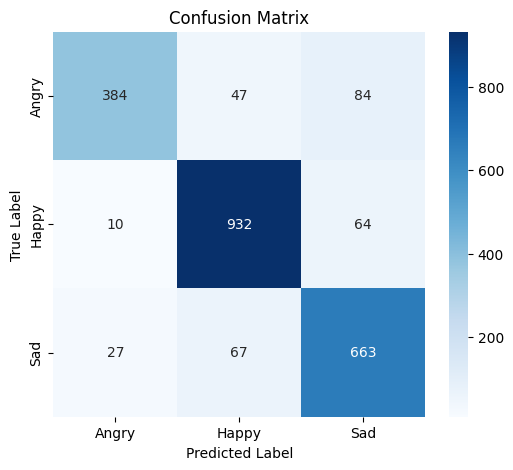

Classification Report:

              precision    recall  f1-score   support

       Angry     0.9121    0.7456    0.8205       515
       Happy     0.8910    0.9264    0.9084      1006
         Sad     0.8175    0.8758    0.8457       757

    accuracy                         0.8687      2278
   macro avg     0.8735    0.8493    0.8582      2278
weighted avg     0.8714    0.8687    0.8677      2278



In [10]:
y_true = np.concatenate([y for _, y in test_ds], axis=0)
preds = model.predict(test_ds, verbose=0)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


2025-09-28 03:32:37.737318: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-28 03:32:38.111207: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1371611136 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


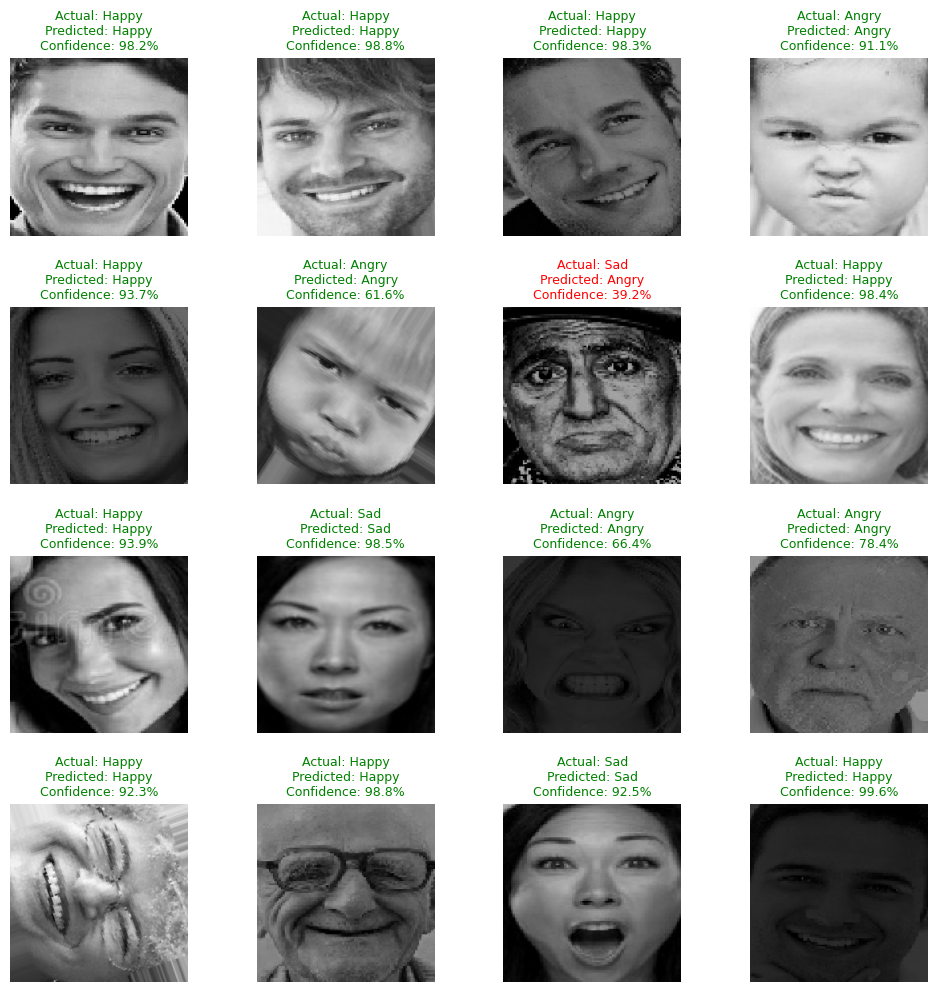

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def plot_actual_vs_predicted_full_multiclass(model, dataset, class_names, num_samples=16):
    # Collect all images and labels from the dataset
    all_images = []
    all_labels = []
    for images, labels in dataset:
        all_images.append(images)
        all_labels.append(labels)
    all_images = tf.concat(all_images, axis=0).numpy()
    all_labels = tf.concat(all_labels, axis=0).numpy()
    
    # Randomly select samples
    idxs = np.random.choice(len(all_images), num_samples, replace=False)
    sampled_images = all_images[idxs]
    sampled_labels = all_labels[idxs]
    
    rows = cols = int(np.ceil(np.sqrt(num_samples)))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()
    
    preds = model.predict(sampled_images)
    pred_labels = np.argmax(preds, axis=1)
    
    for i in range(num_samples):
        img = sampled_images[i].astype("uint8")
        axes[i].imshow(img)
        true_label = class_names[sampled_labels[i]]
        predicted_label = class_names[pred_labels[i]]
        confidence = preds[i][pred_labels[i]]
        color = 'green' if sampled_labels[i] == pred_labels[i] else 'red'
        axes[i].set_title(f"Actual: {true_label}\nPredicted: {predicted_label}\nConfidence: {confidence*100:.1f}%",
                          fontsize=9, color=color)
        axes[i].axis('off')
    
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')
    
    fig.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.show()

class_names = ['Angry', 'Happy', 'Sad']
plot_actual_vs_predicted_full_multiclass(model, test_ds, class_names, num_samples=16)
